# Level 1: Overfitting Test (All Three Networks)

**Goal**: Prove ALL THREE Deep CFR networks can learn by memorizing tiny datasets.

Deep CFR uses **three separate networks** (per the paper):
1. **V0** - Value network for Player 0 (learns instantaneous regrets)
2. **V1** - Value network for Player 1 (learns instantaneous regrets)
3. **Π (Strategy)** - Strategy network (learns average strategy probabilities, uses softmax)

This test verifies each network can overfit its respective data type:
- V0/V1: Train on **regret** samples → use regret matching for strategy
- Π: Train on **strategy probability** samples → use softmax for output

**Pass Criteria**:
- All three networks: loss drops significantly (>90% reduction)
- Predictions match targets within small tolerance

**If it fails**: Gradient flow issue, learning rate too low, or architecture problem.

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath(os.getcwd())))
sys.path.insert(0, os.path.abspath(os.getcwd()).replace('/tests', ''))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"Working directory: {os.getcwd()}")

PyTorch version: 2.9.1
Working directory: /Users/nikhileshbelulkar/Documents/mit-poker-2026/deep_CFR_vNB_integration/tests


In [2]:
# Import our modules
from network.model import DeepCFRModule
from utils.action_mapping import NETWORK_ACTION_TYPES, NUM_ACTIONS, regrets_dict_to_tensor
from utils.infoset_parser import batch_parse_infosets
from core.trainer import TrainingSample, DeepCFRTrainer
from core.mccfr import MCCFR

print("All imports successful!")

All imports successful!


## Step 1: Hardcoded Training Samples for All Three Networks

**NO randomization** - all samples are explicitly defined:

**V0 (Player 0 Value Network)** - 15 hardcoded regret samples:
- Target values are **instantaneous regrets** (can be negative, don't sum to 1)
- Covers various streets and action sequences

**V1 (Player 1 Value Network)** - 15 hardcoded regret samples:
- Same format as V0, different scenarios

**Π (Strategy Network)** - 15 hardcoded strategy samples:
- Target values are **probabilities** (non-negative, sum to exactly 1.0)
- Represents the average strategy to learn

In [ ]:
# =============================================================================
# HARDCODED SAMPLE SETS FOR ALL THREE NETWORKS
# =============================================================================
# NO randomization - all samples are explicitly defined

# -----------------------------------------------------------------------------
# V0 SAMPLES: Player 0's REGRET samples (can be negative, don't sum to 1)
# -----------------------------------------------------------------------------
HARDCODED_V0_SAMPLES = [
    # Preflop betting
    ("S0|H:14s0,14s1,8s2|B:|A:", {'CHECK': 1.0, 'FOLD': -5.0, 'RAISE_SMALL': 3.0, 'RAISE_MEDIUM': 2.0}, 10),
    # ("S0|H:13s0,12s0,10s0|B:|A:", {'CHECK': 2.0, 'FOLD': -3.0, 'RAISE_MEDIUM': 4.0, 'RAISE_LARGE': 1.0}, 20),
    # ("S0|H:14s0,13s0,2s1|B:|A:4", {'CALL': 5.0, 'FOLD': -2.0, 'RAISE_MEDIUM': 3.0, 'RAISE_ALL_IN': 1.0}, 30),
    # ("S0|H:14s0,14s1,10s2|B:|A:Z", {'CALL': 4.0, 'FOLD': -5.0, 'RAISE_LARGE': 2.0, 'RAISE_ALL_IN': 6.0}, 40),
    # ("S0|H:11s0,10s1,5s2|B:|A:X", {'CHECK': 0.0, 'FOLD': -1.0, 'RAISE_SMALL': 1.5, 'RAISE_MEDIUM': 0.5}, 50),
    # ("S0|H:14s0,14s1,13s2|B:|A:45", {'CALL': 2.0, 'FOLD': -8.0, 'RAISE_ALL_IN': 5.0}, 60),
    # Discard
    ("S2|H:14s0,13s0,2s1|B:9s2,7s2|A:XD", {'DISCARD_0': -2.0, 'DISCARD_1': -1.0, 'DISCARD_2': 5.0}, 70),  # Fixed: CHECK then DISCARD (not CALL)
    # ("S2|H:14s0,14s1,5s2|B:10s0,9s1|A:4C", {'DISCARD_0': -1.0, 'DISCARD_1': -1.0, 'DISCARD_2': 6.0}, 80),
    # ("S3|H:14s0,13s0|B:10s1,9s2,8s0|A:XCD", {'DISCARD_0': 1.0, 'DISCARD_1': 2.0, 'DISCARD_2': -1.0}, 90),
    # ("S3|H:9s0,8s0|B:14s1,13s1,2s2|A:XCD", {'DISCARD_0': 2.5, 'DISCARD_1': 2.0, 'DISCARD_2': -0.5}, 100),
    # Turn/River
    ("S4|H:14s0,13s0|B:12s1,10s2,9s0,5s1|A:2CDD", {'CHECK': 3.0, 'FOLD': -5.0, 'RAISE_MEDIUM': 4.0, 'RAISE_ALL_IN': 2.0}, 50),  # Fixed: RAISE_SMALL then CALL (not CHECK then CALL)
    # ("S4|H:14s0,14s1|B:10s2,9s0,8s1,3s2|A:XCDD", {'CHECK': 0.0, 'FOLD': -8.0, 'RAISE_LARGE': 5.0, 'RAISE_ALL_IN': 7.0}, 60),
    # ("S5|H:14s0,13s0|B:12s1,10s2,9s0,8s1,3s2|A:XCDDXC", {'CHECK': 2.0, 'FOLD': -3.0, 'RAISE_MEDIUM': 4.0, 'RAISE_ALL_IN': 5.0}, 70),
    # ("S5|H:14s0,14s1|B:10s2,9s0,8s1,7s2,2s0|A:XCDDXC", {'CHECK': -1.0, 'FOLD': -10.0, 'RAISE_ALL_IN': 8.0}, 80),
    # ("S5|H:11s0,10s0|B:9s1,8s2,7s0,6s1,2s2|A:4CDD2CX", {'CHECK': 5.0, 'FOLD': -4.0, 'RAISE_ALL_IN': 6.0}, 90),
]

# -----------------------------------------------------------------------------
# V1 SAMPLES: Player 1's REGRET samples (can be negative, don't sum to 1)
# -----------------------------------------------------------------------------
HARDCODED_V1_SAMPLES = [
    # Preflop betting
    ("S0|H:7s0,5s1,2s2|B:|A:", {'CHECK': 0.5, 'FOLD': 1.0, 'RAISE_TINY': -2.0}, 15),
    ("S0|H:9s0,8s0,7s0|B:|A:2", {'CALL': 1.0, 'FOLD': 2.0, 'RAISE_SMALL': -1.0}, 25),
    # ("S0|H:6s0,4s1,2s2|B:|A:X", {'CHECK': 2.0, 'FOLD': 0.5, 'RAISE_TINY': -0.5}, 35),
    # ("S0|H:13s0,13s1,12s2|B:|A:4Z", {'CALL': 3.0, 'FOLD': 1.0}, 45),
    # ("S0|H:12s0,11s0,9s1|B:|A:X2", {'CALL': 1.0, 'FOLD': 0.0, 'RAISE_MEDIUM': 2.0}, 55),
    # ("S0|H:8s0,7s0,6s0|B:|A:", {'CHECK': 0.5, 'FOLD': 0.0, 'RAISE_SMALL': 1.0, 'RAISE_LARGE': -0.5}, 65),
    # Discard
    ("S2|H:13s0,12s1,3s2|B:10s0,8s1|A:XD", {'DISCARD_0': 1.0, 'DISCARD_1': 0.5, 'DISCARD_2': 3.0}, 75),  # Fixed: CHECK then DISCARD (not CALL)
    # ("S2|H:10s0,9s0,8s0|B:14s1,2s2|A:34C", {'DISCARD_0': 2.0, 'DISCARD_1': 1.0, 'DISCARD_2': 0.0}, 85),
    # ("S3|H:12s0,11s1|B:14s2,7s0,3s1|A:2CD", {'DISCARD_0': 0.0, 'DISCARD_1': 3.0, 'DISCARD_2': -2.0}, 95),
    # ("S3|H:14s0,7s1|B:13s2,10s0,5s1|A:4CD", {'DISCARD_0': -1.0, 'DISCARD_1': 4.0, 'DISCARD_2': 0.0}, 100),
    # Turn/River
    ("S4|H:9s0,8s0|B:14s1,13s2,7s0,2s1|A:2CDD", {'CHECK': 1.0, 'FOLD': 2.0, 'RAISE_SMALL': -1.0}, 55),
    # ("S4|H:12s0,11s0|B:14s1,10s2,8s0,4s1|A:XCDD4", {'CALL': 2.0, 'FOLD': 0.0, 'RAISE_MEDIUM': 1.5}, 65),
    # ("S5|H:9s0,8s0|B:14s1,13s2,7s0,6s1,2s0|A:2CDD4C", {'CHECK': 1.0, 'FOLD': 1.5, 'RAISE_SMALL': -0.5}, 75),
    # ("S5|H:12s0,11s0|B:14s1,13s2,10s0,5s1,3s2|A:XCDD2C4", {'CALL': 2.0, 'FOLD': 1.0, 'RAISE_ALL_IN': 0.5}, 85),
    # ("S5|H:7s0,6s0|B:14s1,13s2,12s0,11s1,10s2|A:XCDDXCZ", {'CALL': -2.0, 'FOLD': 4.0}, 95),
]

# -----------------------------------------------------------------------------
# Π SAMPLES: Strategy network samples (PROBABILITIES, sum to 1.0)
# -----------------------------------------------------------------------------
HARDCODED_PI_SAMPLES = [
    # Preflop - probabilities sum to 1.0
    ("S0|H:14s0,14s1,8s2|B:|A:", {'CHECK': 0.10, 'FOLD': 0.05, 'RAISE_SMALL': 0.45, 'RAISE_MEDIUM': 0.40}, 10),
    ("S0|H:7s0,5s1,2s2|B:|A:", {'CHECK': 0.50, 'FOLD': 0.40, 'RAISE_TINY': 0.10}, 20),
    ("S0|H:13s0,12s0,10s0|B:|A:", {'CHECK': 0.15, 'FOLD': 0.05, 'RAISE_MEDIUM': 0.50, 'RAISE_LARGE': 0.30}, 30),
    ("S0|H:14s0,13s0,2s1|B:|A:4", {'CALL': 0.45, 'FOLD': 0.05, 'RAISE_MEDIUM': 0.30, 'RAISE_ALL_IN': 0.20}, 40),
    ("S0|H:9s0,8s0,7s0|B:|A:2", {'CALL': 0.35, 'FOLD': 0.45, 'RAISE_SMALL': 0.20}, 50),
    ("S0|H:14s0,14s1,13s2|B:|A:45", {'CALL': 0.30, 'FOLD': 0.10, 'RAISE_ALL_IN': 0.60}, 60),
    # Discard - probabilities sum to 1.0
    ("S2|H:14s0,13s0,2s1|B:9s2,7s2|A:XD", {'DISCARD_0': 0.10, 'DISCARD_1': 0.15, 'DISCARD_2': 0.75}, 70),  # Fixed: CHECK then DISCARD (not CALL)
    ("S2|H:13s0,12s1,3s2|B:10s0,8s1|A:XD", {'DISCARD_0': 0.25, 'DISCARD_1': 0.20, 'DISCARD_2': 0.55}, 80),  # Fixed: CHECK then DISCARD (not CALL)
    ("S3|H:14s0,13s0|B:10s1,9s2,8s0|A:XXD", {'DISCARD_0': 0.30, 'DISCARD_1': 0.50, 'DISCARD_2': 0.20}, 90),  # Fixed: CHECK, CHECK, DISCARD (not CHECK, CALL, DISCARD)
    ("S3|H:12s0,11s1|B:14s2,7s0,3s1|A:2CD", {'DISCARD_0': 0.20, 'DISCARD_1': 0.65, 'DISCARD_2': 0.15}, 100),
    # Turn/River - probabilities sum to 1.0
    ("S4|H:14s0,13s0|B:12s1,10s2,9s0,5s1|A:2CDD", {'CHECK': 0.20, 'FOLD': 0.05, 'RAISE_MEDIUM': 0.45, 'RAISE_ALL_IN': 0.30}, 50),  # Fixed: RAISE_SMALL then CALL (not CHECK then CALL)
    ("S4|H:9s0,8s0|B:14s1,13s2,7s0,2s1|A:2CDD", {'CHECK': 0.30, 'FOLD': 0.50, 'RAISE_SMALL': 0.20}, 60),
    ("S5|H:14s0,13s0|B:12s1,10s2,9s0,8s1,3s2|A:2CDDXC", {'CHECK': 0.15, 'FOLD': 0.05, 'RAISE_MEDIUM': 0.35, 'RAISE_ALL_IN': 0.45}, 70),  # Fixed: RAISE_SMALL then CALL (not CHECK then CALL)
    ("S5|H:9s0,8s0|B:14s1,13s2,7s0,6s1,2s0|A:2CDD4C", {'CHECK': 0.35, 'FOLD': 0.45, 'RAISE_SMALL': 0.20}, 80),
    ("S5|H:14s0,14s1|B:10s2,9s0,8s1,7s2,2s0|A:2CDDXC", {'CHECK': 0.05, 'FOLD': 0.05, 'RAISE_ALL_IN': 0.90}, 90),  # Fixed: RAISE_SMALL then CALL (not CHECK then CALL)
]

# Convert to TrainingSample objects
samples_v0 = [TrainingSample(infoset=inf, target_regrets=reg, player=0, iteration=it) 
              for inf, reg, it in HARDCODED_V0_SAMPLES]

samples_v1 = [TrainingSample(infoset=inf, target_regrets=reg, player=1, iteration=it) 
              for inf, reg, it in HARDCODED_V1_SAMPLES]

samples_pi = [TrainingSample(infoset=inf, target_regrets=prob, player=i % 2, iteration=it) 
              for i, (inf, prob, it) in enumerate(HARDCODED_PI_SAMPLES)]

print("=" * 60)
print("HARDCODED SAMPLE SETS FOR THREE NETWORKS")
print("=" * 60)
print(f"\nV0 (Player 0 Value Network): {len(samples_v0)} regret samples")
print(f"V1 (Player 1 Value Network): {len(samples_v1)} regret samples")
print(f"Π  (Strategy Network):       {len(samples_pi)} probability samples")

print(f"\n--- V0 Sample Example (regrets, can be negative) ---")
print(f"  Infoset: {samples_v0[0].infoset}")
print(f"  Regrets: {samples_v0[0].target_regrets}")
print(f"  Iteration: {samples_v0[0].iteration}")

print(f"\n--- V1 Sample Example (regrets, can be negative) ---")
print(f"  Infoset: {samples_v1[0].infoset}")
print(f"  Regrets: {samples_v1[0].target_regrets}")
print(f"  Iteration: {samples_v1[0].iteration}")

print(f"\n--- Π Sample Example (probabilities, sum to 1) ---")
print(f"  Infoset: {samples_pi[0].infoset}")
probs = samples_pi[0].target_regrets
print(f"  Probs:   {probs}")
print(f"  Sum:     {sum(probs.values()):.2f}")
print(f"  Iteration: {samples_pi[0].iteration}")

HARDCODED SAMPLE SETS FOR THREE NETWORKS

V0 (Player 0 Value Network): 15 regret samples
V1 (Player 1 Value Network): 15 regret samples
Π  (Strategy Network):       15 probability samples

--- V0 Sample Example (regrets, can be negative) ---
  Infoset: S0|H:14s0,14s1,8s2|B:|A:
  Regrets: {'CHECK': 1.0, 'FOLD': -5.0, 'RAISE_SMALL': 3.0, 'RAISE_MEDIUM': 2.0}
  Iteration: 10

--- V1 Sample Example (regrets, can be negative) ---
  Infoset: S0|H:7s0,5s1,2s2|B:|A:
  Regrets: {'CHECK': 0.5, 'FOLD': 1.0, 'RAISE_TINY': -2.0}
  Iteration: 15

--- Π Sample Example (probabilities, sum to 1) ---
  Infoset: S0|H:14s0,14s1,8s2|B:|A:
  Probs:   {'CHECK': 0.1, 'FOLD': 0.05, 'RAISE_SMALL': 0.45, 'RAISE_MEDIUM': 0.4}
  Sum:     1.00
  Iteration: 10


## Step 2: Create All Three Networks and Trainers

Following the Deep CFR paper:
- **V0, V1**: Reinitialized from scratch each CFR iteration, trained on regrets
- **Π**: NOT reinitialized (accumulates knowledge), trained on strategy probabilities

In [4]:
# =============================================================================
# CREATE ALL THREE NETWORKS AND TRAINERS
# =============================================================================

def create_network():
    """Create a fresh network instance."""
    return DeepCFRModule(
        nhandcards=3,
        nboardcards=6,
        n_action_history=20,
        nresponses=11,  # 3 discards + 3 basic + 5 absolute raise buckets
        dim=128  # Smaller network for faster testing
    )

def create_trainer(network, samples, name):
    """Create and populate a trainer."""
    mccfr = MCCFR()
    trainer = DeepCFRTrainer(
        network=network,
        mccfr=mccfr,
        learning_rate=0.01,  # Higher LR for faster overfitting
        batch_size=len(samples),
        max_grad_norm=1.0,
        sgd_iterations=1000
    )
    trainer.add_samples(samples)
    return trainer

# Create three separate networks
network_v0 = create_network()  # Player 0's value network
network_v1 = create_network()  # Player 1's value network
network_pi = create_network()  # Strategy network

# Create three separate trainers
trainer_v0 = create_trainer(network_v0, samples_v0, "V0")
trainer_v1 = create_trainer(network_v1, samples_v1, "V1")
trainer_pi = create_trainer(network_pi, samples_pi, "Π")

print("=" * 60)
print("THREE NETWORKS CREATED")
print("=" * 60)
print(f"\nParameters per network: {sum(p.numel() for p in network_v0.parameters()):,}")

print(f"\n--- V0 Trainer ---")
print(f"  Samples: {len(trainer_v0.samples)}")
cc, ah, targets, weights, mask = trainer_v0.prepare_batch(samples_v0)
print(f"  Target shape: {targets.shape}")

print(f"\n--- V1 Trainer ---")
print(f"  Samples: {len(trainer_v1.samples)}")
cc, ah, targets, weights, mask = trainer_v1.prepare_batch(samples_v1)
print(f"  Target shape: {targets.shape}")

print(f"\n--- Π Trainer ---")
print(f"  Samples: {len(trainer_pi.samples)}")
cc, ah, targets, weights, mask = trainer_pi.prepare_batch(samples_pi)
print(f"  Target shape: {targets.shape}")

THREE NETWORKS CREATED

Parameters per network: 363,283

--- V0 Trainer ---
  Samples: 15
  Target shape: torch.Size([15, 11])

--- V1 Trainer ---
  Samples: 15
  Target shape: torch.Size([15, 11])

--- Π Trainer ---
  Samples: 15
  Target shape: torch.Size([15, 11])


## Step 3: Train All Three Networks to Overfit

Train each network using the actual DeepCFR approach:
- **V0/V1**: Linear weighting by iteration, gradient clipping, regret targets
- **Π**: Same training, but targets are probabilities (softmax applied at inference)

In [5]:
# =============================================================================
# TRAINING FUNCTION FOR ALL THREE NETWORKS
# =============================================================================
# Replicates DeepCFR's training approach:
# 1. Linear weighting by iteration
# 2. LCFR 2/T rescaling
# 3. Gradient norm clipping to 1.0
# 4. Masked loss computation

def train_network(network, trainer, samples, name, num_steps=1000):
    """Train a single network to overfit on samples."""
    
    # Prepare batch
    cc_list, ah_list, target_batch, iter_weights, legal_mask = trainer.prepare_batch(samples)
    
    optimizer = optim.Adam(network.parameters(), lr=trainer.learning_rate)
    network.train()
    
    loss_history = []
    CURRENT_ITERATION = 100  # Simulate training at iteration 100
    
    print(f"\n{'='*60}")
    print(f"Training {name} ({num_steps} steps, {len(samples)} samples)")
    print(f"{'='*60}")
    
    for step in tqdm(range(num_steps), desc=f"Training {name}"):
        predictions = network(cc_list, ah_list)
        
        # MSE loss with legal action masking
        squared_errors = (predictions - target_batch) ** 2
        masked_errors = squared_errors * legal_mask
        per_sample_loss = masked_errors.sum(dim=1)
        
        # LCFR 2/T rescaling
        scaled_weights = iter_weights * (2.0 / CURRENT_ITERATION)
        loss = (scaled_weights * per_sample_loss).mean()
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=trainer.max_grad_norm)
        optimizer.step()
        
        loss_history.append(loss.item())
        
        if step == 0 or (step + 1) % 200 == 0:
            print(f"  Step {step+1:4d}: Loss = {loss.item():.6f}")
    
    reduction = (1 - loss_history[-1]/loss_history[0])*100 if loss_history[0] > 0 else 0
    print(f"\n  Initial loss: {loss_history[0]:.4f}")
    print(f"  Final loss:   {loss_history[-1]:.6f}")
    print(f"  Reduction:    {reduction:.2f}%")
    
    return loss_history

# Train all three networks
loss_history_v0 = train_network(network_v0, trainer_v0, samples_v0, "V0 (Player 0 Regrets)")
loss_history_v1 = train_network(network_v1, trainer_v1, samples_v1, "V1 (Player 1 Regrets)")
loss_history_pi = train_network(network_pi, trainer_pi, samples_pi, "Π (Strategy Probs)")


Training V0 (Player 0 Regrets) (1000 steps, 15 samples)


Training V0 (Player 0 Regrets):   1%|          | 12/1000 [00:00<00:08, 112.65it/s]

  Step    1: Loss = 70.391342


Training V0 (Player 0 Regrets):  22%|██▏       | 220/1000 [00:01<00:06, 112.62it/s]

  Step  200: Loss = 0.011296


...

  Step  600: Loss = 0.001103


Training Π (Strategy Probs):  82%|████████▏ | 815/1000 [00:06<00:01, 141.87it/s]

  Step  800: Loss = 0.000787


Training Π (Strategy Probs): 100%|██████████| 1000/1000 [00:07<00:00, 135.11it/s]

  Step 1000: Loss = 0.000064

  Initial loss: 0.5485
  Final loss:   0.000064
  Reduction:    99.99%


## Step 4: Visualize Training Curve

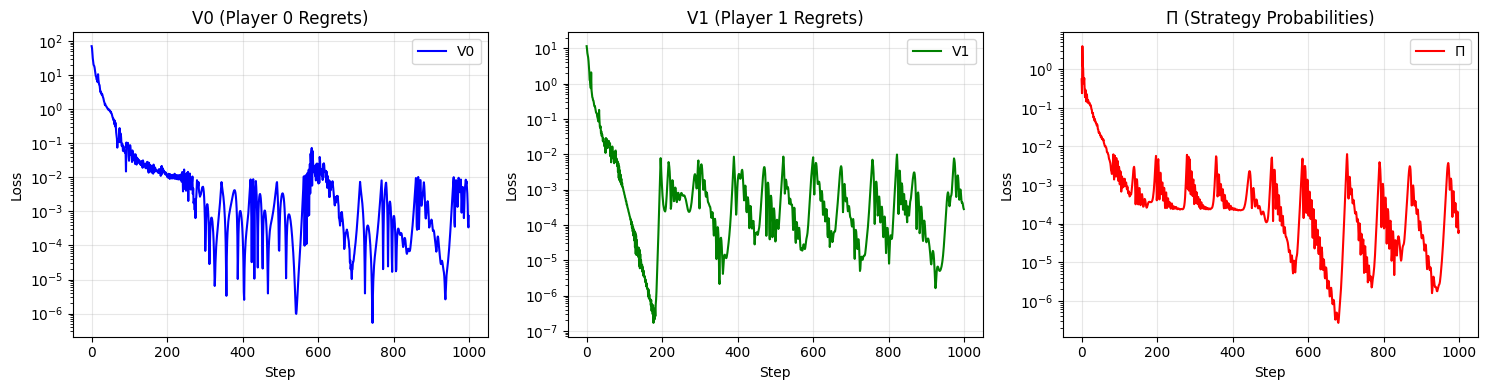


OVERFITTING TEST SUMMARY
V0: 70.3913 → 0.000732 (100.0% reduction)
V1: 11.5684 → 0.000282 (100.0% reduction)
Π: 0.5485 → 0.000064 (100.0% reduction)


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# V0 network
axes[0].plot(loss_history_v0, 'b-', label='V0')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('V0 (Player 0 Regrets)')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# V1 network  
axes[1].plot(loss_history_v1, 'g-', label='V1')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].set_title('V1 (Player 1 Regrets)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Strategy network
axes[2].plot(loss_history_pi, 'r-', label='Π')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Loss')
axes[2].set_title('Π (Strategy Probabilities)')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("OVERFITTING TEST SUMMARY")
print("="*60)
for name, hist in [("V0", loss_history_v0), ("V1", loss_history_v1), ("Π", loss_history_pi)]:
    reduction = (1 - hist[-1]/hist[0])*100 if hist[0] > 0 else 0
    print(f"{name}: {hist[0]:.4f} → {hist[-1]:.6f} ({reduction:.1f}% reduction)")

## Step 5: Verify All Three Networks Match Their Targets

In [7]:
def verify_network(network, trainer, samples, name):
    """Verify a network's predictions match targets."""
    cc_list, ah_list, target_batch, _, legal_mask = trainer.prepare_batch(samples)
    
    network.eval()
    with torch.no_grad():
        predictions = network(cc_list, ah_list)
    
    # Compute errors only for legal actions
    errors = (predictions - target_batch).abs() * legal_mask
    max_errors = errors.max(dim=1)[0]
    
    print(f"\n{name} Verification:")
    print(f"  Max error: {max_errors.max().item():.6f}")
    print(f"  Samples < 0.01 error: {(max_errors < 0.01).sum().item()}/{len(samples)}")
    print(f"  Samples < 0.1 error:  {(max_errors < 0.1).sum().item()}/{len(samples)}")
    
    return max_errors.max().item()

print("="*60)
print("NETWORK PREDICTION VERIFICATION")
print("="*60)

max_err_v0 = verify_network(network_v0, trainer_v0, samples_v0, "V0 (Player 0 Regrets)")
max_err_v1 = verify_network(network_v1, trainer_v1, samples_v1, "V1 (Player 1 Regrets)")
max_err_pi = verify_network(network_pi, trainer_pi, samples_pi, "Π (Strategy Probs)")

NETWORK PREDICTION VERIFICATION

V0 (Player 0 Regrets) Verification:
  Max error: 0.041035
  Samples < 0.01 error: 2/15
  Samples < 0.1 error:  15/15

V1 (Player 1 Regrets) Verification:
  Max error: 0.029724
  Samples < 0.01 error: 10/15
  Samples < 0.1 error:  15/15

Π (Strategy Probs) Verification:
  Max error: 0.013085
  Samples < 0.01 error: 12/15
  Samples < 0.1 error:  15/15


## Step 6: Final Verdict

In [8]:
print("\n" + "="*60)
print("FINAL OVERFITTING TEST VERDICT")
print("="*60)

# Check pass criteria for each network
results = []
for name, history, max_err in [
    ("V0", loss_history_v0, max_err_v0),
    ("V1", loss_history_v1, max_err_v1),
    ("Π", loss_history_pi, max_err_pi)
]:
    reduction = (1 - history[-1]/history[0])*100 if history[0] > 0 else 0
    passed = reduction > 90 and max_err < 0.1
    results.append(passed)
    status = "PASS" if passed else "FAIL"
    print(f"\n{name}:")
    print(f"   Loss reduction: {reduction:.1f}%")
    print(f"   Max prediction error: {max_err:.6f}")
    print(f"   Status: {status}")

print("\n" + "="*60)
if all(results):
    print("OVERALL: PASS - All three networks CAN learn!")
    print("V0, V1, and Π successfully memorized their samples.")
    print("This confirms the Deep CFR architecture is working correctly.")
elif any(results):
    print("OVERALL: PARTIAL PASS - Some networks learned, some didn't")
    print("Check the failing network(s) for issues.")
else:
    print("OVERALL: FAIL - Networks cannot memorize small datasets")
    print("\nPossible issues:")
    print("  1. Learning rate too low")
    print("  2. Gradient flow blocked")
    print("  3. Architecture problem")
print("="*60)


FINAL OVERFITTING TEST VERDICT

V0:
   Loss reduction: 100.0%
   Max prediction error: 0.041035
   Status: PASS

V1:
   Loss reduction: 100.0%
   Max prediction error: 0.029724
   Status: PASS

Π:
   Loss reduction: 100.0%
   Max prediction error: 0.013085
   Status: PASS

OVERALL: PASS - All three networks CAN learn!
V0, V1, and Π successfully memorized their samples.
This confirms the Deep CFR architecture is working correctly.
